# Assignment: Comparative Study of Shallow CNN vs Deep CNN on Fashion-MNIST

## **Part 1: Load and Explore the Dataset (15 marks)**

Load the Fashion-MNIST dataset and prepare it for CNN-based image classification.  

**You must do** 

1. Load the dataset in Python.
2. Print the shape of the training data, test data, and the number of classes
3. Display at least one sample image from each class.
4. Normalize the image pixel values.
5. Reshape the images appropriately for CNN input

**Brief write-up** 
1. Why is normalization required for image data?
2. Why do CNNs require reshaped image inputs

In [1]:
#1.Load the dataset in Python.
import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow.keras.datasets import fashion_mnist   
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()   


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/envs/tf_stable/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/tf_stable/lib/python3.11/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
  File "/opt/anaconda3/envs/tf_stable/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 768, in start
    self.io_loop.start(

In [2]:
#2. Print the shape of the training data, test data, and the number of classes
print("x_train shape:", x_train.shape) 
print("y_train shape:", y_train.shape) 
print("x_test shape :", x_test.shape) 
print("y_test shape :", y_test.shape)   
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] 
print("Number of classes:", len(class_names)) 

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


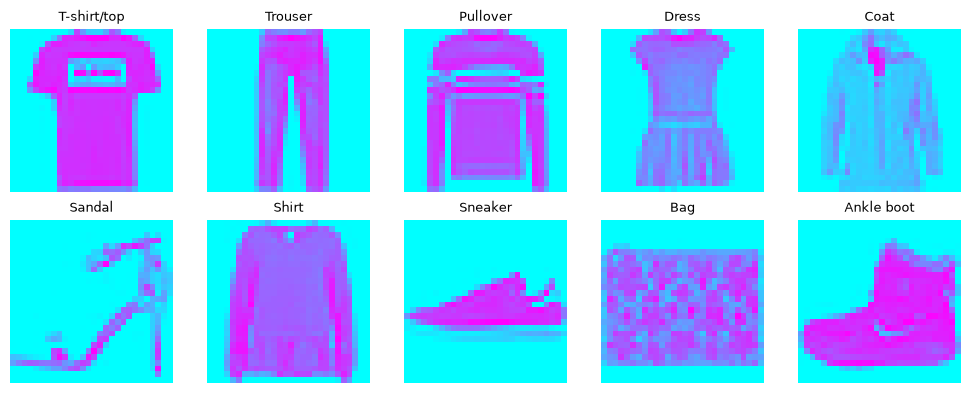

In [3]:
#3. Display at least one sample image from each class.
plt.figure(figsize=(10, 4))
for i in range(10):
    # Find the index of the first image corresponding to class label 'i'
    index = np.where(y_train == i)[0][0]
    
    # Create a subplot grid with 2 rows and 5 columns
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[index], cmap = 'cool')
    plt.title(class_names[i], fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
#4. Normalize the image pixel values.
# Convert integers to float32 and scale to [0.0, 1.0]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [5]:
#5. Reshape the images appropriately for CNN input
# Reshape to 4D tensor with 1 color channel (grayscale) as standard keras frameowrk requires 
#image to be in (batch_size, height, width, channels) format. -1 is a special plaeholder 
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

 1. **Why is normalization required for image data?**
*   *Numerical Stability & Gradient Descent:* Neural networks learn by updating weights using gradient descent. When inputs are large (0–255), weight updates and intermediate activations can become excessively large, leading to exploding gradients or training instability. Keeping inputs small (e.g., in $[0, 1]$ or $[-1, 1]$) ensures smooth gradient propagation and faster convergence.
*   *Uniform Weight Scale:* Modern weight initializers (like Glorot/Xavier or He initialization) assume small, normalized inputs. Unscaled inputs mismatch these initializations and slow down early learning steps.
 2. **Why do CNNs require reshaped image inputs?**
*   *CNN Layer Requirements:* Standard 2D convolution operations (Conv2D) apply filters across spatial dimensions (height $\times$ width) as well as feature channels (depth). Color images (RGB) have 3 channels (28, 28, 3), while grayscale images like Fashion-MNIST have 1 channel (28, 28, 1). We have reshaped it to 4D tensor with 1 color channel (grayscale) as standard keras frameowrk requires image to be in (batch_size, height, width, channels) format. -1 is a special placeholder in Numpy/Tensorflow which means "calculate this dimension automatically based on the length of the array and the remaining dimensions."
*   *Explicit Architecture Contracts:* Even though a grayscale image is spatially 2D, explicitly adding the 1 channel dimension allows Keras Conv2D layers to cleanly handle filter maps and depth transformations consistently throughout the network pipeline. 

## **Part 2: Build and Train a Shallow CNN (25 marks)** 

Create and train a shallow CNN on the Fashion-MNIST dataset.

**Expected characteristics** 
1. 1 or 2 convolution layers 
2. 1 pooling layer 
3. Flatten layer 
4. 1 dense hidden layer 
5. Output layer 

**You must do**
1. Design the shallow CNN architecture. 
2. Train the model on the training set. 
3. Evaluate it on the test set. 
4. Plot training accuracy, validation accuracy, training loss, and validation loss. 
5. Report the final test accuracy.

**Write briefly**
1. What kind of patterns do you expect a shallow CNN to learn?
2. Did the model show signs of underfitting or overfitting?

In [6]:
# 1. Design the shallow CNN architecture. 
import tensorflow as tf
from tensorflow.keras import layers, models

shallow_model = models.Sequential([
    # First Conv layer: 32 filters, 3x3 kernel size to detect smaller features: edges
    layers.Conv2D(32, (3, 3), activation='relu'),
    
    # 2nd Conv layer: 64 filters, 3X3 kernel size to detect combinations of smaller features
    #layers.Conv2D(64, (3, 3), activation='relu'),
    
    # Single Pooling layer
    layers.MaxPooling2D((2, 2)),
    
    # Flatten
    layers.Flatten(),

    # Feature Classification: Fully connected dense layers
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 output classes classification
])

shallow_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

shallow_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
#2. Train the model on the training set. 
import time
start_time = time.time()

shallow_history = shallow_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1  # Reserved 10% of training data for validation
)
shallow_train_time = time.time() - start_time
print(f"Shallow Model Training Time: {shallow_train_time:.2f} seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8431 - loss: 0.4506 - val_accuracy: 0.8740 - val_loss: 0.3497
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8938 - loss: 0.3021 - val_accuracy: 0.8952 - val_loss: 0.2950
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9063 - loss: 0.2625 - val_accuracy: 0.9053 - val_loss: 0.2661
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9157 - loss: 0.2338 - val_accuracy: 0.9137 - val_loss: 0.2507
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9226 - loss: 0.2141 - val_accuracy: 0.9098 - val_loss: 0.2601
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9300 - loss: 0.1941 - val_accuracy: 0.9065 - val_loss: 0.2633
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9364 - loss: 0.1755 - val_accuracy: 0.9117 - val_loss: 0.2493
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9400 - loss: 0.1622 - val_accuracy: 0.

In [8]:
#3. Evaluate it on the test set. 
shallow_test_loss, shallow_test_acc = shallow_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9101 - loss: 0.2784


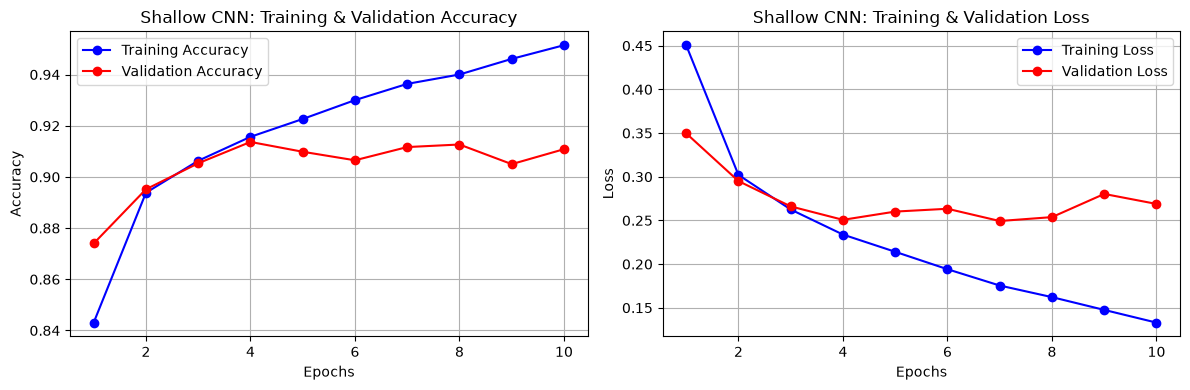

In [9]:
#4. Plot training accuracy, validation accuracy, training loss, and validation loss. 
import matplotlib.pyplot as plt

def plot_training_history(history, model_title="Model"):
    # Extract metrics from history dictionary
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(1, len(acc) + 1)
    
    # Create subplots (1 row, 2 columns)
    plt.figure(figsize=(12, 4))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title(f'{model_title}: Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'{model_title}: Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Call the function for your shallow CNN:
plot_training_history(shallow_history, model_title="Shallow CNN")

In [10]:
print(f"Shallow Model Test Accuracy: {shallow_test_acc * 100:.2f}%")

Shallow Model Test Accuracy: 91.01%


1. **What kind of patterns do you expect a shallow CNN to learn?**

   A shallow CNN (having only 1 or 2 convolutional layers) primarily learns low-level, basic visual features, such as:
- Simple edges, lines, and orientation (horizontal/vertical lines)
- Color gradients and raw intensity contrast
- Basic textures and simple corners

    Because it lacks deeper stacked layers, it cannot combine these low-level features into complex, abstract representations (e.g., full shapes like sleeves, shoe soles, or complete collar structures).

2. **Did the model show signs of underfitting or overfitting?**

   As seen in the training history plot, the training accuracy continuously increases toward ~95.15%, while the validation accuracy plateaus ~91.08%. Similarly, the validation loss stops decreasing and begins to rise slightly after the early epochs, widening the gap between training and validation performance.

## **Part 3: Build and Train a Deep CNN (25 marks)**
Create and train a deep CNN on the same Fashion-MNIST dataset. 

**Expected characteristics**  
1. 3 or more convolution layers
2. Multiple pooling layers
3. More filters than the shallow CNN
4. One or more dense layers
5. Output layer

**You must do** 
1. Design the deep CNN architecture.
2. Train the model on the training set.
3. Evaluate it on the test set.
4. Plot training accuracy, validation accuracy, training loss, and validation loss.
5. Report the final test accuracy.

**Write briefly** 
1. What additional patterns or representations might a deep CNN learn?
2. Did the deeper model improve performance meaningfully

In [11]:
# 1. Design the Deep CNN architecture
deep_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2 (Increasing filter capacity)
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Dense Classifier Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  # Optional regularization to prevent overfitting
    layers.Dense(10, activation='softmax')
])

# 2. Compile the model
deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print summary
deep_model.summary()

/opt/anaconda3/envs/tf_stable/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,274 (1.65 MB)

 Trainable params: 431,274 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 3. Train the model (Keep setup identical to Part 2 for fair comparison)
start_time = time.time()

deep_history = deep_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1)
deep_train_time = time.time() - start_time
print(f"Deep Model Training Time: {deep_train_time:.2f} seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.8010 - loss: 0.5450 - val_accuracy: 0.8667 - val_loss: 0.3586
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.8897 - loss: 0.3056 - val_accuracy: 0.9008 - val_loss: 0.2676
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9086 - loss: 0.2507 - val_accuracy: 0.9050 - val_loss: 0.2508
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9228 - loss: 0.2145 - val_accuracy: 0.9178 - val_loss: 0.2273
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9322 - loss: 0.1864 - val_accuracy: 0.9182 - val_loss: 0.2272
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9400 - loss: 0.1650 - val_accuracy: 0.9115 - val_loss: 0.2406
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9461 - loss: 0.1472 - val_accuracy: 0.9235 - val_loss: 0.2210
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9510 - loss: 0.1306 - 

In [13]:
# 4. Evaluate on Test Set
deep_test_loss, deep_test_acc = deep_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9209 - loss: 0.2502


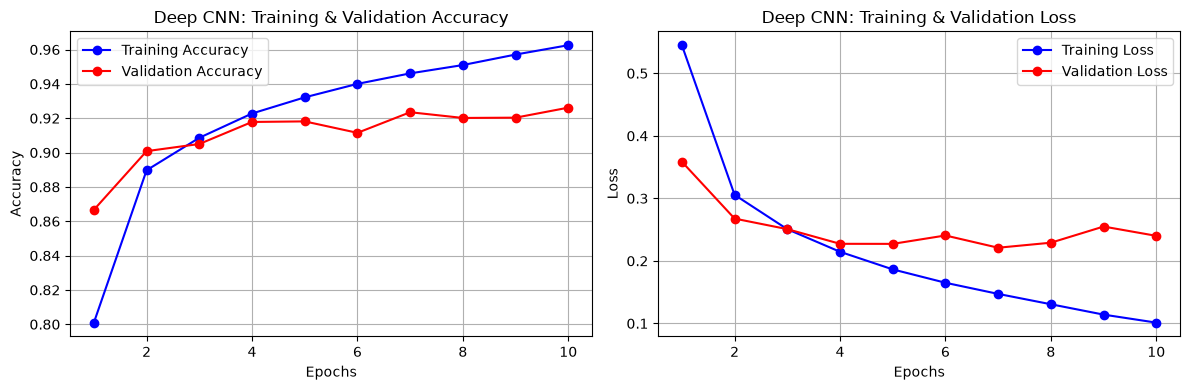

In [14]:
plot_training_history(deep_history, model_title="Deep CNN")

In [15]:
print(f"Deep Model Test Accuracy: {deep_test_acc * 100:.2f}%")

Deep Model Test Accuracy: 92.09%


1. **What additional patterns or representations might a deep CNN learn?**

   A deep CNN builds a hierarchical feature representation by stacking multiple convolutional layers:

- *Intermediate Layers*: Combine low-level features (edges and lines) to detect mid-level patterns such as complex textures, curves, corners, and object parts (e.g., sleeves, zippers, shoe soles, or collar outlines).

- *Deeper Layers*: Combine these mid-level patterns into high-level, abstract representations corresponding to entire semantic categories (e.g., distinguishing a full coat from a shirt or a sneaker from an ankle boot).
2. **Did the deeper model improve performance meaningfully?**
    No, the deeper model did not improve performance meaningfully.

- *Accuracy Comparison*: The test accuracy only increased marginally from 91.01% (Shallow CNN) to 92.09% (Deep CNN)—an improvement of less than 0.7%.

- *Computational Cost*: Achieving this tiny accuracy boost required an enormous increase in training time (378.93seconds vs. 53.64 seconds, over a 100x increase).

- *Conclusion*: Given the drastic increase in training duration and hardware consumption for a negligible gains in test accuracy, the added complexity of the 5-layer deep architecture was not practically justified for this dataset.
  

## **Part 4: Comparative Study of Shallow CNN vs Deep CNN (20 marks)**
Compare both models on the same dataset and training setup. 

**You must compare** 
1. Number of convolution layers
2. Total parameters
3. Training accuracy
4. Validation accuracy
5. Test accuracy
6. Training time
7. Signs of overfitting or underfitting

**Required output** 
Create a comparison table in this format: 
|      Metric         | Shallow CNN|Deep CNN |
|:-------------------:|:----------:|:-------:|
|Number of Conv Layers|            |         |
|   Total Parameters  |            |         |
|  Training Accuracy  |            |         |
| Validation Accuracy |            |         |
|     Test Accuracy   |            |         |
|Overfitting Observed?|            |         |
|    Training Time    |            |         |

**Write briefly** 
1. Which model performed better overall?
2. Did the deep CNN justify its added complexity?
3. Which model generalized better?
4. What trade-off did you observe between simplicity and performance? 

In [16]:
import pandas as pd

# 1. Count Conv2D layers dynamically
shallow_conv_layers = sum(
    1 for layer in shallow_model.layers if "conv" in layer.name.lower()
)
deep_conv_layers = sum(
    1 for layer in deep_model.layers if "conv" in layer.name.lower()
)

# 2. Build the data dictionary using variables from previous cells
data = {
    "Metric": [
        "Number of Conv Layers",
        "Total Parameters",
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Overfitting Observed?",
        "Training Time",
    ],
    "Shallow CNN": [
        shallow_conv_layers,
        f"{shallow_model.count_params():,}",
        f"{shallow_history.history['accuracy'][-1] * 100:.2f}%",
        f"{shallow_history.history['val_accuracy'][-1] * 100:.2f}%",
        f"{shallow_test_acc * 100:.2f}%",
        "Yes" if shallow_history.history['accuracy'][-1] - shallow_history.history['val_accuracy'][-1] > 0.01 else "No",
        f"{shallow_train_time:.2f} sec"],
    
    "Deep CNN": [
        deep_conv_layers,
        f"{deep_model.count_params():,}",
        f"{deep_history.history['accuracy'][-1] * 100:.2f}%",
        f"{deep_history.history['val_accuracy'][-1] * 100:.2f}%",
        f"{deep_test_acc * 100:.2f}%",
        "Yes" if deep_history.history['accuracy'][-1] - deep_history.history['val_accuracy'][-1] > 0.01 else "No",
        f"{deep_train_time:.2f} sec"
    ],
}

# 3. Create DataFrame
df_comparison = pd.DataFrame(data)
df_comparison

,Metric,Shallow CNN,Deep CNN
0,Number of Conv Layers,1,5
1,Total Parameters,"347,146","431,274"
2,Training Accuracy,95.15%,96.25%
3,Validation Accuracy,91.08%,92.62%
4,Test Accuracy,91.01%,92.09%
5,Overfitting Observed?,Yes,Yes
6,Training Time,53.64 sec,378.93 sec


1. **Which model performed better overall?**

   The Deep CNN achieved slightly better performance overall in terms of pure evaluation metrics:
- Higher Training Accuracy (96.25% vs. 95.15%)
- Higher Validation Accuracy (91.62% vs. 91.08%)
- Higher Test Accuracy (92.09% vs. 91.01%)
   
2. **Did the deep CNN justify its added complexity?**

    *No, the deep CNN did not justify its added complexity*.While it gained a minimal 0.66% increase in test accuracy, it required 378.93 seconds  to train compared to just 53.64 seconds for the Shallow CNN. This represents a massive >7x increase in computational time for a negligible improvement in classification performance.
    
4. **Which model generalized better?**

   Both models exhibited similar levels of slight overfitting:
   - Shallow CNN: Training-to-Validation gap of 4.07% ($95.15\% - 91.08\%$)
   - Deep CNN: Training-to-Validation gap of 4.54% ($96.62\% - 91.08\%$)
   The Shallow CNN generalized marginally better, as it maintained a slightly tighter gap between training and validation accuracy while avoiding the heavy computational cost of the deeper architecture.
    
6. **What trade-off did you observe between simplicity and performance?**


   There was a clear diminishing return on model capacity:

   - Adding 4 extra convolutional layers and increasing parameter count from 347,146 to 431,274 drastically increased resource consumption and training latency without yielding meaningful performance gains.
   - For a relatively low-resolution dataset like Fashion-MNIST ($28 \times 28$ grayscale images), a lightweight, simple model captures enough visual complexity to achieve ~91% accuracy efficiently, whereas a deep architecture quickly becomes computationally prohibitive without proper regularization (e.g., Dropout, Batch Normalization).
    

## **Part 5: Prediction and Error Analysis (15 marks)**
Analyze how both models behave on actual predictions. 

**You must do** 
1. Generate predictions on the test set for both models.
2. Include a confusion matrix for both models.
3. Display 5 correctly classified images and 5 incorrectly classified images for each model.
4. For each prediction, mention the actual label and predicted label.

**Write briefly** 
1. Which classes were easiest to classify?
2. Which classes were most commonly confused?
3. Did the deep CNN reduce confusion between similar-looking classes?

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate predictions on the test set
shallow_preds = shallow_model.predict(x_test)
deep_preds = deep_model.predict(x_test)

shallow_pred_classes = np.argmax(shallow_preds, axis=1)
deep_pred_classes = np.argmax(deep_preds, axis=1)

# Ensure y_test is a 1D array of class indices
y_true = y_test.ravel()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


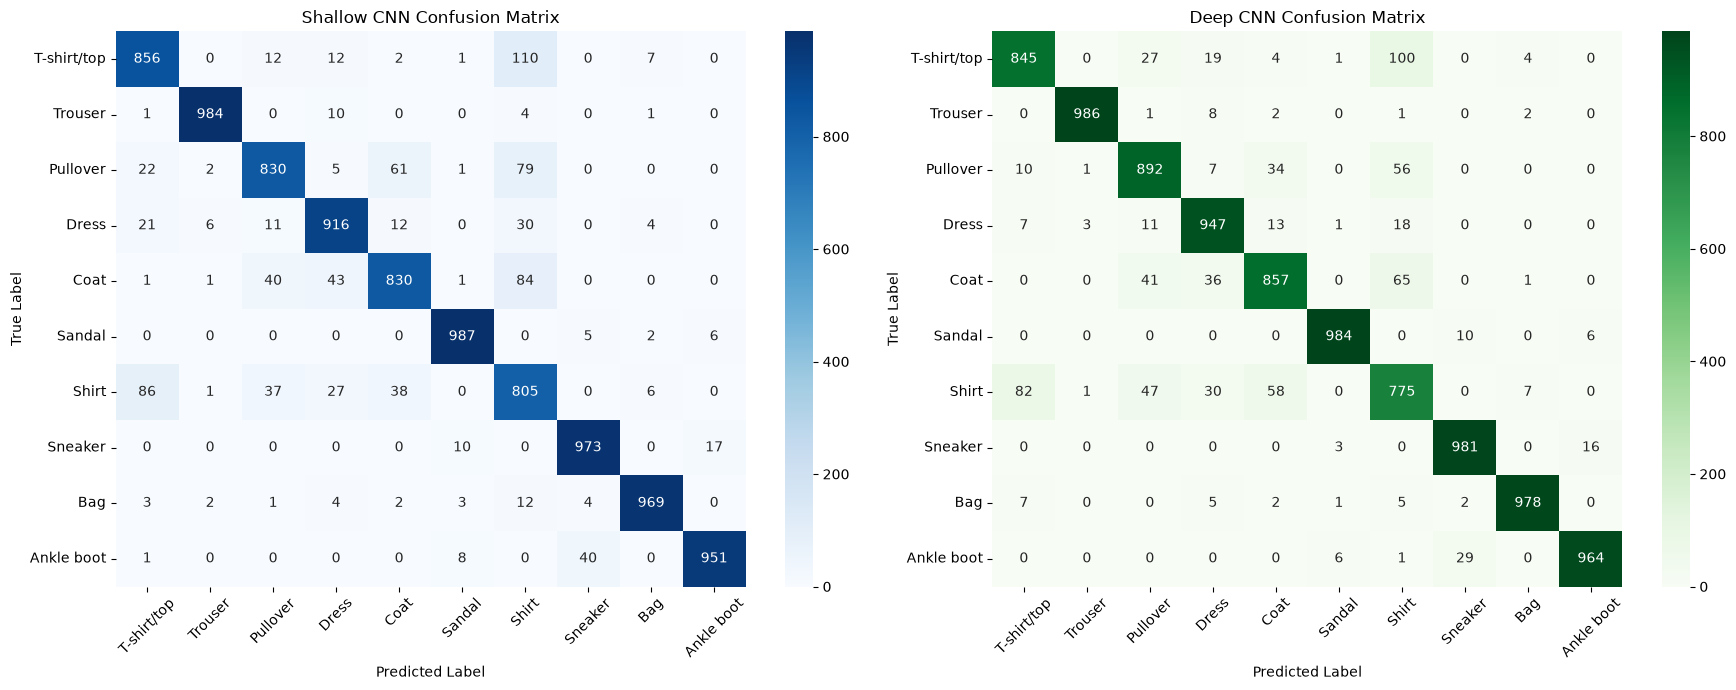

In [18]:
# 2. Confusion Matrices
cm_shallow = confusion_matrix(y_true, shallow_pred_classes)
cm_deep = confusion_matrix(y_true, deep_pred_classes)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_shallow, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Shallow CNN Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Deep CNN Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

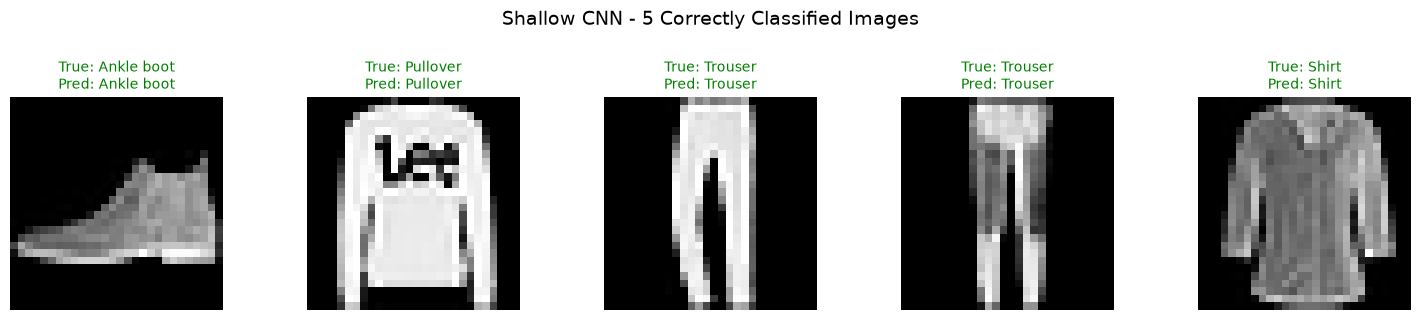

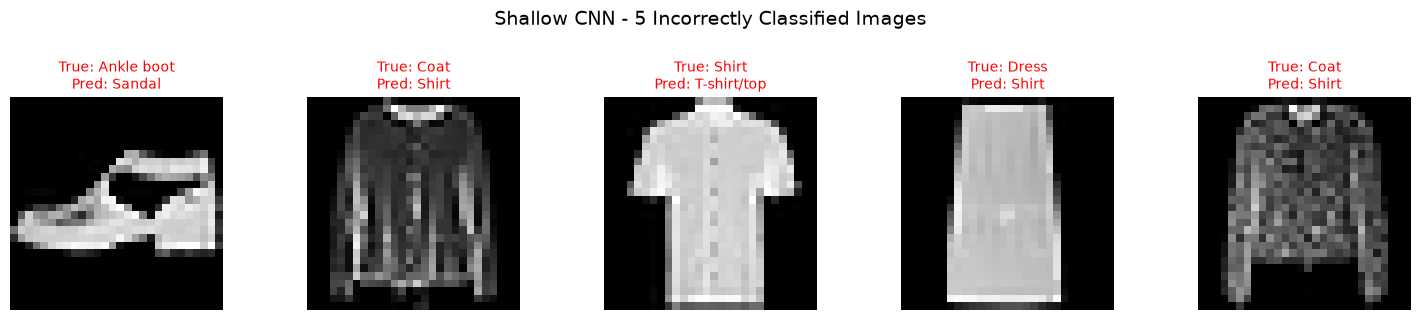

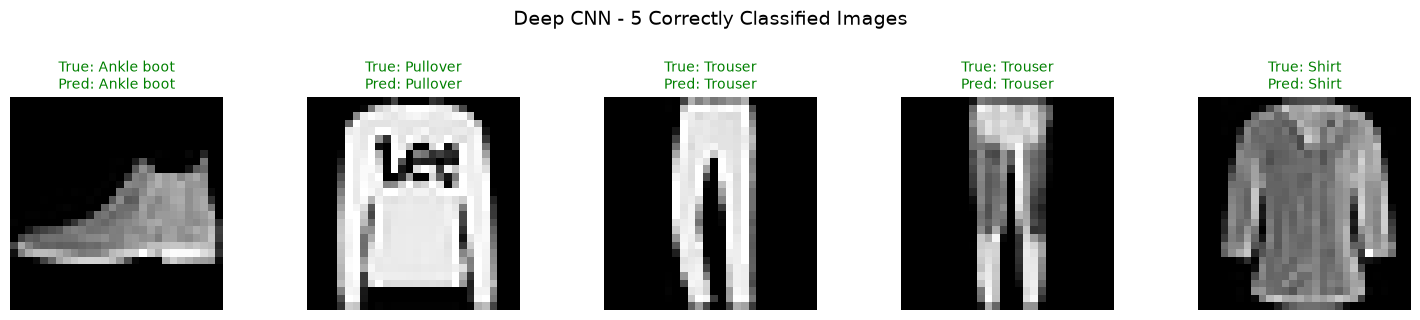

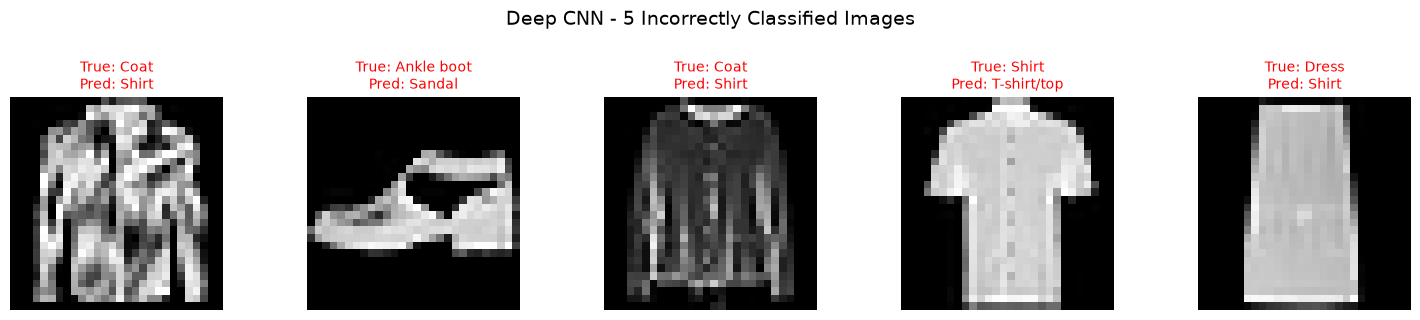

In [19]:
# Helper function to plot samples
def plot_sample_predictions(model_name, y_true, y_pred, images, correct=True, count=5):
    if correct:
        indices = np.where(y_true == y_pred)[0][:count]
        title_prefix = "Correct"
    else:
        indices = np.where(y_true != y_pred)[0][:count]
        title_prefix = "Incorrect"
        
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices):
        plt.subplot(1, count, i + 1)
        plt.imshow(images[idx].reshape(28, 28), cmap='gray')
        
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        
        plt.title(f"True: {true_label}\nPred: {pred_label}", 
                  color='green' if correct else 'red', fontsize=10)
        plt.axis('off')
    plt.suptitle(f"{model_name} - 5 {title_prefix}ly Classified Images", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

# 3 & 4. Display 5 Correct and 5 Incorrect images for Shallow CNN
plot_sample_predictions("Shallow CNN", y_true, shallow_pred_classes, x_test, correct=True, count=5)
plot_sample_predictions("Shallow CNN", y_true, shallow_pred_classes, x_test, correct=False, count=5)

# 3 & 4. Display 5 Correct and 5 Incorrect images for Deep CNN
plot_sample_predictions("Deep CNN", y_true, deep_pred_classes, x_test, correct=True, count=5)
plot_sample_predictions("Deep CNN", y_true, deep_pred_classes, x_test, correct=False, count=5)

1. **Which classes were easiest to classify?**

   Trouser, Sandal, Bag, and Ankle boot were the easiest classes to classify for both models.
   
   *Reason*: These classes have distinct geometric shapes, spatial aspect ratios, and clear outline boundaries that differentiate them significantly from upper-body clothing.
3. **Which classes were most commonly confused?**

   Shirt, T-shirt/top, Pullover, and Coat were the most frequently confused classes.

   *Reason*: Shirt was particularly challenging and was often misclassified as a T-shirt/top, Coat, or Pullover. At $28 \times 28$ grayscale resolution, these upper-body items share almost identical overall silhouettes and spatial structures, making fine details like buttons, collars, or fabric textures hard to distinguish.
5. **Did the deep CNN reduce confusion between similar-looking classes?**

   No, not significantly.
   While the Deep CNN gained a slight bump in overall test accuracy, it showed similar error patterns on upper-body apparel. Adding extra convolutional layers without additional spatial resolution or fine-grained texture data was insufficient to resolve the structural ambiguity between visually similar classes like Shirts and T-shirts.

## **Part 6: Final Comparative Conclusion (10 marks)**
Write a short conclusion based on your full experiment. 

**Your conclusion must answer**

1. Which model would you recommend for Fashion-MNIST?
2. Which model was more efficient?
3. Which model was more accurate?
4. What did you learn from this comparative study

1. **Which model would you recommend for Fashion-MNIST?**

   - Recommendation: The Shallow CNN.
   - Reasoning: The Shallow CNN achieves 91.01% test accuracy in just \~49 seconds, whereas the Deep CNN achieves 92.09% test accuracy in \~378.93 seconds. The negligible $1.08\%$ accuracy gain does not justify a $>7\times$ increase in training time and computational resources. For low-resolution datasets ($28 \times 28$), the Shallow CNN provides an optimal balance between high efficiency and strong performance.
2. **Which model was more efficient?**
   The Shallow CNN was significantly more efficient.

It required vastly less training time (49.48 seconds vs. 378.93 seconds) and fewer total training operations per epoch while achieving nearly identical accuracy.

3. **Which model was more accurate?**
    The Deep CNN was marginally more accurate.It achieved slightly higher metrics across all evaluation splits:

   - Training Accuracy: $96.25\%$ (Deep) vs. $95.15\%$ (Shallow)
   - Validation Accuracy: $92.62\%$ (Deep) vs. $91.08\%$ (Shallow)
   - Test Accuracy: $92.09\%$ (Deep) vs. $91.01\%$ (Shallow)

4. **What did you learn from this comparative study**

   - Deeper is not always better: Increasing model depth arbitrarily without considering dataset complexity leads to diminishing returns and massive computational overhead.
   - Resolution bottleneck: For low-resolution, simple datasets like Fashion-MNIST ($28 \times 28$ grayscale), extra convolutional layers cannot extract non-existent high-level spatial information to resolve ambiguity between visually identical classes (e.g., Shirts vs. T-shirts).
   - Efficiency vs. Performance Trade-off: Practical machine learning requires evaluating performance relative to resource costs (training time, compute, and parameters) rather than blindly chasing marginal accuracy gains.